In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import spottedpy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
plt.rcParams["pdf.fonttype"] = "truetype"
plt.rcParams["axes.grid"] = False

In [6]:
adata_full = sc.read_h5ad("data/adata_with_drug2cell_scores.h5ad")

In [7]:
adata = adata_full.copy()

In [8]:
# Cell type labels
drug_labels = [
    "CHEMBL1200976|IDARUBICIN HYDROCHLORIDE",
    "CHEMBL1200645|ETOPOSIDE PHOSPHATE",
    "CHEMBL1200475|DAUNORUBICIN CITRATE",
    "CHEMBL1096885|VALRUBICIN",
    "CHEMBL44657|ETOPOSIDE",
    "CHEMBL1200699|DOXYCYCLINE",
    "CHEMBL2364574|DOXYCYCLINE CALCIUM",
    "CHEMBL3989740|DOXYCYCLINE HYCLATE",
    "CHEMBL65375|TIPIRACIL HYDROCHLORIDE",
    "CHEMBL2048028|LIFITEGRAST",
]

quiescence_labels = ["G0_arrested", "Fast_cycling"]

In [9]:
# Extract drug2cell scores to adata.obs
drug2cell_adata = adata.uns["drug2cell"]
drug_scores = pd.DataFrame(
    drug2cell_adata[:, drug_labels].X.toarray(),
    index=adata.obs_names,
    columns=drug_labels,
)
adata.obs[drug_labels] = drug_scores

In [10]:
# Define a function to scale scores
def scale_scores(adata, drug_names, batch_column="batch"):
    scaler = MinMaxScaler()

    for batch in adata.obs[batch_column].unique():
        adata_subset = adata[adata.obs[batch_column] == batch]

        # Scale scores for the given score names
        adata_subset.obs[drug_names] = scaler.fit_transform(
            adata_subset.obs[drug_names]
        )

        # Update the main adata object with scaled scores
        adata.obs.loc[adata.obs[batch_column] == batch, drug_names] = adata_subset.obs[
            drug_names
        ].values

In [11]:
# Apply scaling to signatures
scale_scores(adata, drug_labels, batch_column="batch")

In [12]:
def calculate_hotspots(adata, labels, filter_columns=None, filter_value=None):
    for label in tqdm(labels):
        adata = sp.create_hotspots(
            adata,
            column_name=label,
            neighbours_parameters=6,
            relative_to_batch=True,
            number_hotspots=True,
            filter_columns=filter_columns,
            filter_value=filter_value,
        )
    return adata

In [13]:
adata = calculate_hotspots(adata, drug_labels, filter_columns="tumour_cells", filter_value=1)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:30<00:00, 15.03s/it]


In [14]:
drug_hotspots = [label + "_hot" for label in drug_labels]

In [15]:
# Define primary and comparison variables
primary_variables = ["G0_arrested_hot", "Fast_cycling_hot"]

# Calculate distances
distances = sp.calculateDistances(
    adata,
    primary_variables=primary_variables,
    comparison_variables=drug_hotspots,
    empty_hotspot_default_to_max_distance=False,
    split_by_slide_in_batch=True,
    hotspot_number=True,
)

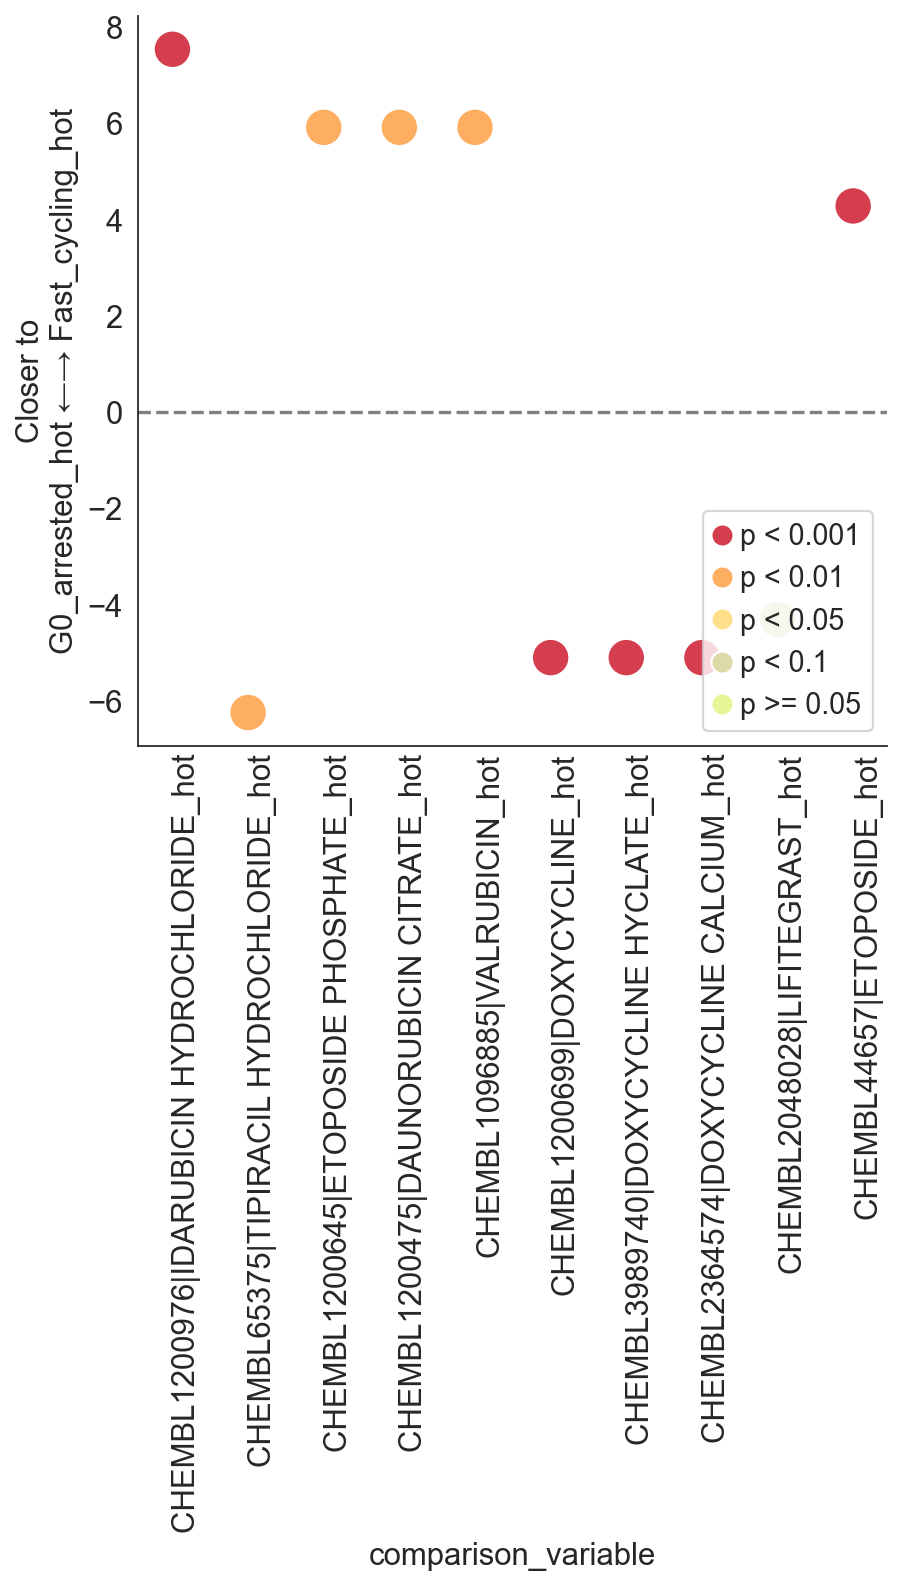

In [16]:
sp.plot_custom_scatter(
    data=distances,
    primary_vars=["G0_arrested_hot", "Fast_cycling_hot"],
    comparison_vars=drug_hotspots,
    bubble_size=(300, 300),
    fig_size=(6, 6),
    save_path="figures/spottedpy_drug_hotspots.pdf",
    compare_distribution_metric="median",
)

In [17]:
def plot_multiple_hotspots(
    adata,
    signatures,
    thresholds=None,
    combined_col=None,
    palette=None,
    plot_kwargs=None,
):
    if thresholds is None:
        thresholds = {sig: 0 for sig in signatures}

    def combine_signatures(row):
        positive = [sig for sig in signatures if row[sig] > thresholds[sig]]
        if len(positive) == 0:
            return "none"
        elif len(positive) == 1:
            return positive[0]
        else:
            return "+".join(sorted(positive))

    if combined_col is None:
        combined_col = f"{'_'.join(signatures)}"

    # Remove old colors if exist
    if f"{combined_col}_colors" in adata.uns:
        del adata.uns[f"{combined_col}_colors"]

    # Compute combined signature
    adata.obs[combined_col] = adata.obs.apply(combine_signatures, axis=1)
    adata.obs[combined_col] = adata.obs[combined_col].replace("none", np.nan)
    adata.obs[combined_col] = (
        adata.obs[combined_col].astype("category").cat.remove_categories([np.nan])
    )

    # Assign palette for categorical plotting
    if palette is not None:
        categories = adata.obs[combined_col].cat.categories
        try:
            colors = [palette[c] for c in categories]
        except KeyError as e:
            raise KeyError(f"Palette dict is missing a colour for category: {e}")
        adata.uns[f"{combined_col}_colors"] = colors

    # Sort AnnData so combined signature spots are plotted on top
    adata_plot = adata[adata.obs[combined_col].isna().sort_values().index, :].copy()

    # Prepare plotting
    plot_kwargs = plot_kwargs or {}
    plot_kwargs.setdefault("edgecolor", "none")
    plot_kwargs.setdefault("linewidth", 0)

    # Ensure save works: assign default filename if missing
    if "save" not in plot_kwargs or plot_kwargs["save"] is None:
        library_id = plot_kwargs.get("library_id", "plot")
        plot_kwargs["save"] = f"{library_id}_{combined_col}_hotspots.pdf"

    # Squidpy/Scanpy requires extension in save string
    if plot_kwargs["save"] and not any(
        plot_kwargs["save"].endswith(ext) for ext in [".pdf", ".png", ".svg", ".jpg"]
    ):
        plot_kwargs["save"] += ".pdf"

    sq.pl.spatial_scatter(adata_plot, color=combined_col, **plot_kwargs)

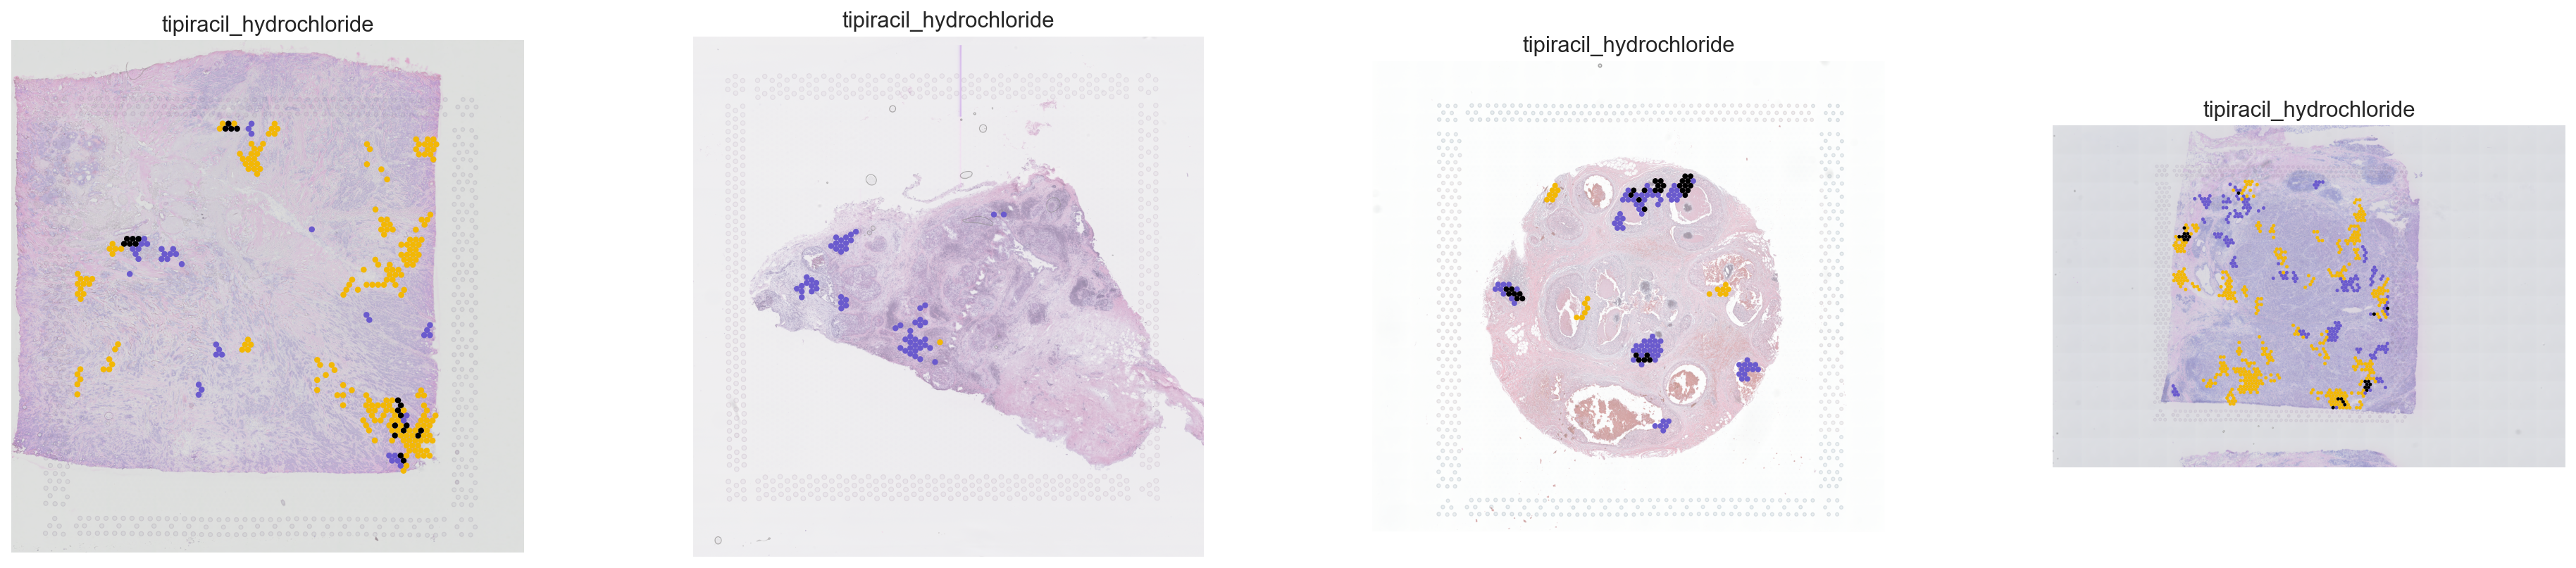

In [18]:
plot_multiple_hotspots(
    adata,
    signatures=["G0_arrested_hot", "CHEMBL65375|TIPIRACIL HYDROCHLORIDE_hot"],
    combined_col="tipiracil_hydrochloride",
    palette={
        "G0_arrested_hot": "#6A5ACD",
        "CHEMBL65375|TIPIRACIL HYDROCHLORIDE_hot": "#F2B705",
        "CHEMBL65375|TIPIRACIL HYDROCHLORIDE_hot+G0_arrested_hot": "#000000",
    },
    plot_kwargs={
        "library_id": ["4", "0", "5", "7"],
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "spottedpy_tipiracil_hydrochloride_g0.pdf",
    },
)

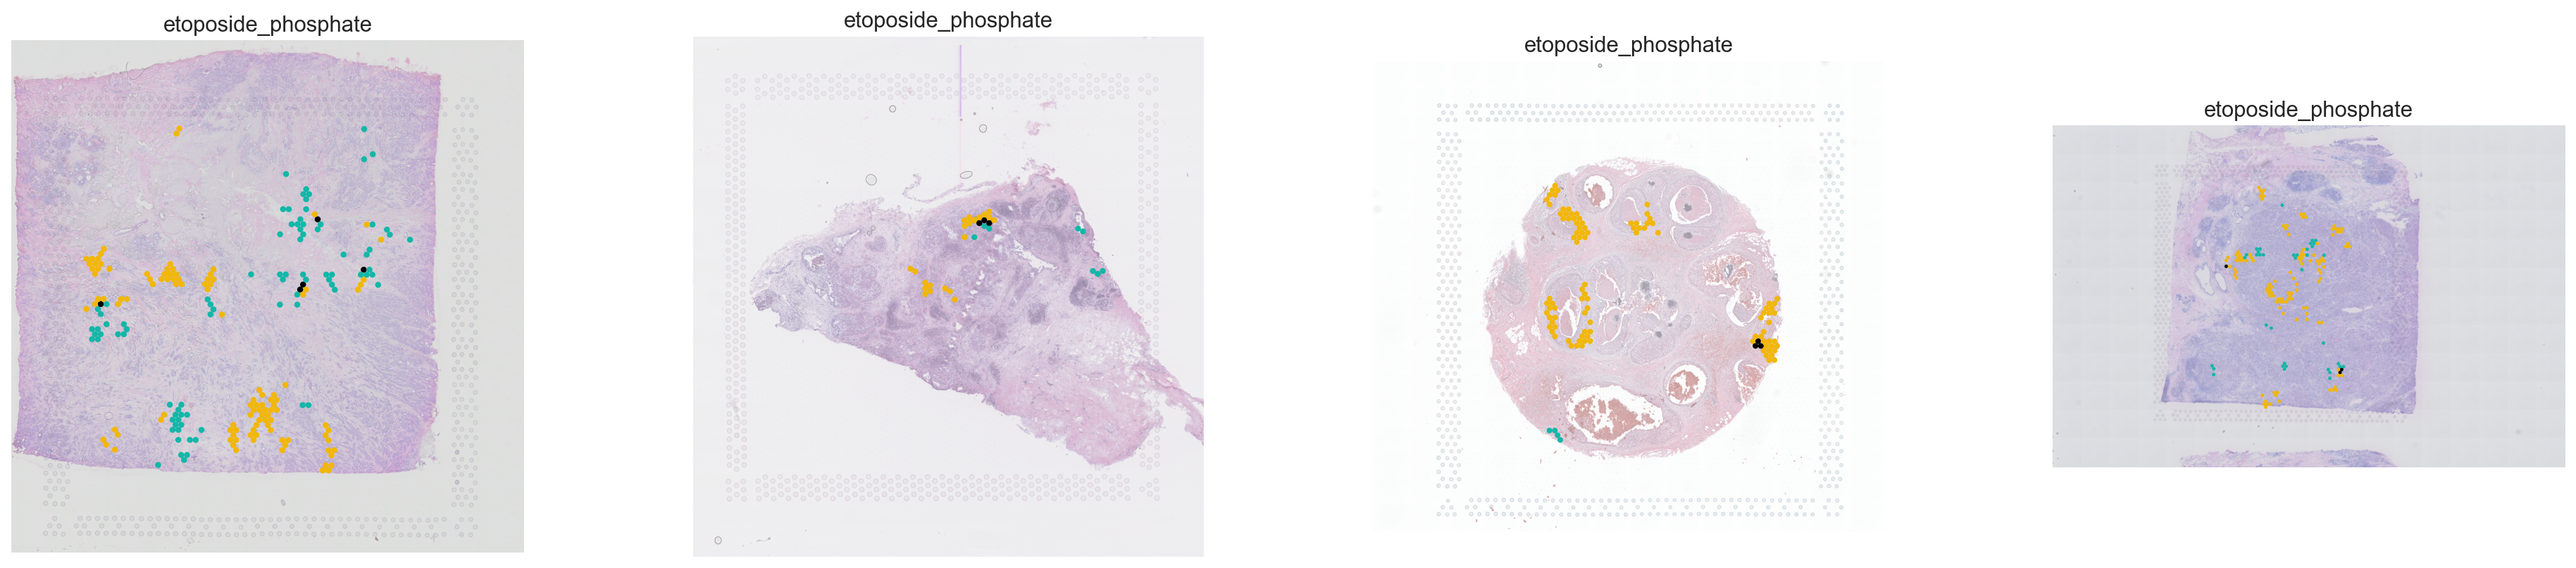

In [20]:
plot_multiple_hotspots(
    adata,
    signatures=["Fast_cycling_hot", "CHEMBL1200645|ETOPOSIDE PHOSPHATE_hot"],
    combined_col="etoposide_phosphate",
    palette={
        "Fast_cycling_hot": "#12B7A8",
        "CHEMBL1200645|ETOPOSIDE PHOSPHATE_hot": "#F2B705",
        "CHEMBL1200645|ETOPOSIDE PHOSPHATE_hot+Fast_cycling_hot": "#000000",
    },
    plot_kwargs={
        "library_id": ["4", "0", "5", "7"],
        "library_key": "batch",
        "figsize": (6, 6),
        "img_alpha": 0.5,
        "legend_loc": None,
        "size": 1.6,
        "save": "spottedpy_etoposide_phosphate.pdf",
    },
)